# Preprocessing 
## GEO ScRNA-seq Dataset ID: GSE212966.
Dataset retreived from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE212966 \
Datset name: Single-cell RNA-seq reveals immune landscape of pancreatic cancer

In [33]:
# Core imports you still need in notebook cells
import os
import sys
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import re

from collections import defaultdict

# Import setup utilities + constants from config/environment.py
from config.environment import (
    set_random_seeds,
    configure_scanpy,
    configure_matplotlib,
    ROOT_DIR,
    RAW_DATA_DIR,
)

# Run shared setup
set_random_seeds()
configure_scanpy()
configure_matplotlib()

print("Environment setup complete")
print(f"Python version: {sys.version}")
print(f"Scanpy version: {sc.__version__}")
print(f"Current directory: {os.getcwd()}")
print(f"Root directory: {ROOT_DIR}") # project root dir 
print(f"Raw Data directory: {RAW_DATA_DIR}")

2026-04-16 14:25:29 INFO: Random seeds set to 42


Environment setup complete
Python version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:02:02) 
[Clang 18.1.8 ]
Scanpy version: 1.10.3
Current directory: /Users/iriskwon/Documents/CG_Final_Proj_Dir/CompGenFinalProject
Root directory: /Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj
Raw Data directory: /Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj/Raw_Data


In [59]:
LOCAL_DIR = Path.cwd()
DATASETS_DIR = str(RAW_DATA_DIR) + "/GSE212966_RAW"
RESULTS_DIR = str(ROOT_DIR) + "/Preprocessing_Results"

print(LOCAL_DIR)
print(ROOT_DIR)
print(RESULTS_DIR)
print(RAW_DATA_DIR)
print(DATASETS_DIR)

/Users/iriskwon/Documents/CG_Final_Proj_Dir/CompGenFinalProject
/Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj
/Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj/Preprocessing_Results
/Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj/Raw_Data
/Users/iriskwon/Library/CloudStorage/OneDrive-JohnsHopkins/CG_Final_Proj/Raw_Data/GSE212966_RAW


In [60]:
os.listdir(RESULTS_DIR) # EMPTY TO BEGIN WITH 

[]

In [24]:
files = os.listdir(DATASETS_DIR)
print(files)

['GSM6567157_PDAC1_matrix.mtx.gz', 'GSM6567160_PDAC3_matrix.mtx.gz', 'GSM6567161_PDAC4_matrix.mtx.gz', 'GSM6567165_ADJ1_matrix.mtx.gz', 'GSM6567166_ADJ2_matrix.mtx.gz', 'GSM6567167_ADJ3_matrix.mtx.gz', 'GSM6567169_ADJ4_matrix.mtx.gz', 'GSM6567159_PDAC2_genes.tsv.gz', 'GSM6567171_ADJ6_barcodes.tsv.gz', 'GSM6567159_PDAC2_matrix.mtx.gz', 'GSM6567170_ADJ5_genes.tsv.gz', 'GSM6567161_PDAC4_genes.tsv.gz', 'GSM6567169_ADJ4_genes.tsv.gz', 'GSM6567165_ADJ1_genes.tsv.gz', 'GSM6567157_PDAC1_barcodes.tsv.gz', 'GSM6567170_ADJ5_matrix.mtx.gz', 'GSM6567160_PDAC3_barcodes.tsv.gz', 'GSM6567163_PDAC5_barcodes.tsv.gz', 'GSM6567166_ADJ2_barcodes.tsv.gz', 'GSM6567159_PDAC2_barcodes.tsv.gz', 'GSM6567167_ADJ3_barcodes.tsv.gz', 'GSM6567163_PDAC5_genes.tsv.gz', 'GSM6567171_ADJ6_matrix.mtx.gz', 'GSM6567171_ADJ6_genes.tsv.gz', 'GSM6567160_PDAC3_genes.tsv.gz', 'GSM6567170_ADJ5_barcodes.tsv.gz', 'GSM6567167_ADJ3_genes.tsv.gz', 'GSM6567165_ADJ1_barcodes.tsv.gz', 'GSM6567166_ADJ2_genes.tsv.gz', 'GSM6567164_PDAC6_barc

In [25]:
len(files)

36

In [35]:
gsm_to_files = defaultdict(list)

for f in files:
    gsm = f.split('_')[0]
    gsm_to_files[gsm].append(f)

gsm_to_files = dict(gsm_to_files)

# Verification
for gsm, flist in gsm_to_files.items():
    print(f"{gsm}: {len(flist)} files found")

GSM6567157: 3 files found
GSM6567160: 3 files found
GSM6567161: 3 files found
GSM6567165: 3 files found
GSM6567166: 3 files found
GSM6567167: 3 files found
GSM6567169: 3 files found
GSM6567159: 3 files found
GSM6567171: 3 files found
GSM6567170: 3 files found
GSM6567163: 3 files found
GSM6567164: 3 files found


In [36]:
len(gsm_to_files) # 12 total unique samples

12

In [42]:
adatas = []

for gsm, flist in gsm_to_files.items():
    print(f"Loading sample {gsm}...")
    # 1. Identify raw filenames
    mtx_file = [f for f in flist if 'matrix' in f][0]
    genes_file = [f for f in flist if 'genes' in f][0]
    barcodes_file = [f for f in flist if 'barcodes' in f][0]
    
    # 2. Build full paths using os.path.join
    mtx_path = os.path.join(DATASETS_DIR, mtx_file)
    genes_path = os.path.join(DATASETS_DIR, genes_file)
    barcodes_path = os.path.join(DATASETS_DIR, barcodes_file)
    
    # 3. Load and Transpose
    adata = sc.read_mtx(mtx_path).T
    
    # 4. Load Genes and Barcodes using the full paths
    genes_df = pd.read_csv(genes_path, header=None, sep='\t')
    barcodes_df = pd.read_csv(barcodes_path, header=None, sep='\t')
    
    # Assign names
    adata.var_names = genes_df[1].values
    adata.var['ensembl_id'] = genes_df[0].values
    adata.obs_names = barcodes_df[0].values
    
    # Add Meta
    sample_name = mtx_file.split('_')[1] 
    adata.obs['gsm'] = gsm
    adata.obs['sample_id'] = sample_name
    adata.obs['condition'] = 'PDAC' if 'PDAC' in sample_name else 'ADJ'
    
    adata.var_names_make_unique()
    adatas.append(adata)

Loading sample GSM6567157...
Loading sample GSM6567160...
Loading sample GSM6567161...
Loading sample GSM6567165...
Loading sample GSM6567166...
Loading sample GSM6567167...
Loading sample GSM6567169...
Loading sample GSM6567159...
Loading sample GSM6567171...
Loading sample GSM6567170...
Loading sample GSM6567163...
Loading sample GSM6567164...


In [44]:
# Create a list of names that matches the order of your 'adatas' list
sample_keys = [a.obs['sample_id'].iloc[0] for a in adatas]

In [46]:
sample_keys

['PDAC1',
 'PDAC3',
 'PDAC4',
 'ADJ1',
 'ADJ2',
 'ADJ3',
 'ADJ4',
 'PDAC2',
 'ADJ6',
 'ADJ5',
 'PDAC5',
 'PDAC6']

In [45]:
# join='inner' is perfect for scGPT to keep a consistent gene vocabulary
adata = sc.concat(adatas, join='inner', label='batch', 
                  keys=sample_keys, 
                  index_unique="_")

In [47]:
adata

AnnData object with n_obs × n_vars = 71074 × 36601
    obs: 'gsm', 'sample_id', 'condition', 'batch'

In [48]:
print(adata.obs['sample_id'].value_counts())
print(adata.obs['condition'].value_counts())

sample_id
PDAC1    8056
PDAC4    6628
PDAC3    6551
PDAC2    6436
ADJ6     6386
ADJ2     6366
ADJ1     6341
ADJ4     5799
PDAC6    5460
PDAC5    4943
ADJ5     4738
ADJ3     3370
Name: count, dtype: int64
condition
PDAC    38074
ADJ     33000
Name: count, dtype: int64


In [52]:
target_order = [
    'PDAC1', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', 'PDAC6',
    'ADJ1', 'ADJ2', 'ADJ3', 'ADJ4', 'ADJ5', 'ADJ6'
]

adata.obs['sample_id'] = pd.Categorical(
    adata.obs['sample_id'],
    categories=target_order,
    ordered=True
)

adata = adata[adata.obs.sort_values('sample_id').index].copy()

In [56]:
adata.obs['sample_id'].unique()

['PDAC1', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', ..., 'ADJ2', 'ADJ3', 'ADJ4', 'ADJ5', 'ADJ6']
Length: 12
Categories (12, object): ['PDAC1' < 'PDAC2' < 'PDAC3' < 'PDAC4' ... 'ADJ3' < 'ADJ4' < 'ADJ5' < 'ADJ6']

In [63]:
# Calculate metrics if not already done
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Plot violin plots for all 12 samples
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    groupby='sample_id',
    rotation=90,
    multi_panel=True,
)

plt.suptitle('Raw QC plots', fontsize=20)
plt.savefig(os.path.join(RESULTS_DIR, 'raw_qc_plots_all.png'), bbox_inches='tight', dpi=300)
plt.close()

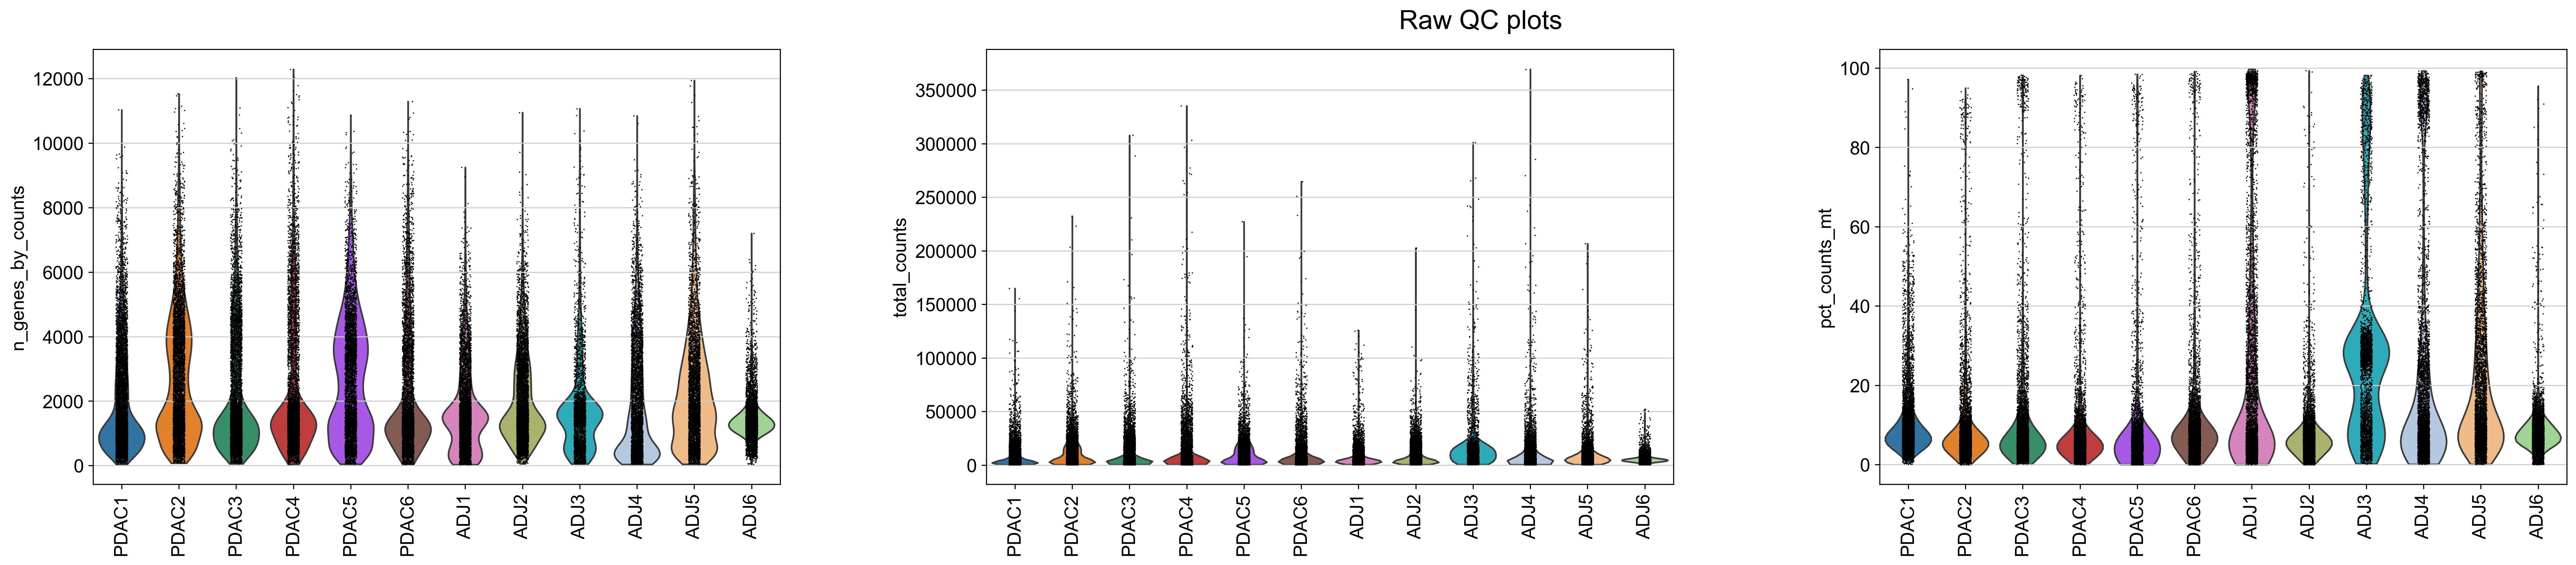

In [ ]:
from IPython.display import Image

display(Image(filename=os.path.join(RESULTS_DIR, "raw_qc_plots_all.png")))


Observations: 
- Obvious doublets detected in PDAC2 and PDAC5 
- ADJ3 has high `pct_counts_mt`

In [ ]:
print(f"Cells remaining before QC: {adata.n_obs}")

adata = adata[(adata.obs.n_genes_by_counts > 500) & # remove empty droplets 
              (adata.obs.n_genes_by_counts < 7500) & # remove obvi doublets
              (adata.obs.pct_counts_mt < 15), :].copy() # safer mt cutoff 

print(f"Cells remaining after QC: {adata.n_obs}")

# capture raw counts nefore transforming 
adata.layers["counts"] = adata.X.copy()

Cells remaining before QC: 71074
Cells remaining after QC: 51318


In [ ]:
!d

In [68]:
adata.n_vars

36601

In [ ]:
# save raw counts for scgpt 
adata.layers["counts"] = adata.X.copy()

# Save the full, filtered, raw-count object
# Includes all 36k cells 
adata.write_h5ad(os.path.join(RESULTS_DIR, "PDAC_ADJ_cleaned_full_raw.h5ad"), compression="gzip")

In [84]:
# Load the saved h5ad file
merged_adata = sc.read_h5ad(os.path.join(RESULTS_DIR, "PDAC_ADJ_cleaned_full_raw.h5ad"))
print(f"Loaded adata object: {merged_adata.shape}")
print(merged_adata)

Loaded adata object: (51318, 36601)
AnnData object with n_obs × n_vars = 51318 × 36601
    obs: 'gsm', 'sample_id', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sample_id_colors'
    layers: 'counts'


In [85]:
sc.pp.filter_genes(merged_adata, min_cells=1)

filtered out 5031 genes that are detected in less than 1 cells


In [86]:
print(f"Filtered adata object: {merged_adata.shape}")

Filtered adata object: (51318, 31570)


In [78]:
merged_adata.obs['sample_id'].unique()

['PDAC1', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', ..., 'ADJ2', 'ADJ3', 'ADJ4', 'ADJ5', 'ADJ6']
Length: 12
Categories (12, object): ['PDAC1' < 'PDAC2' < 'PDAC3' < 'PDAC4' ... 'ADJ3' < 'ADJ4' < 'ADJ5' < 'ADJ6']

In [70]:
adata.obs['sample_id'].unique()

['PDAC1', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', ..., 'ADJ2', 'ADJ3', 'ADJ4', 'ADJ5', 'ADJ6']
Length: 12
Categories (12, object): ['PDAC1' < 'PDAC2' < 'PDAC3' < 'PDAC4' ... 'ADJ3' < 'ADJ4' < 'ADJ5' < 'ADJ6']

In [73]:
adata

AnnData object with n_obs × n_vars = 51318 × 36601
    obs: 'gsm', 'sample_id', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sample_id_colors'
    layers: 'counts'

In [79]:
merged_adata

AnnData object with n_obs × n_vars = 51318 × 36601
    obs: 'gsm', 'sample_id', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sample_id_colors'
    layers: 'counts'

In [82]:
# Use merged_adata (the loaded file) for HVG selection
# Normalize and Logarithmize for HVG selection
sc.pp.normalize_total(merged_adata, target_sum=1e4)
sc.pp.log1p(merged_adata)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
sc.pp.filter_genes(merged_adata, min_cells=1)

In [ ]:
# Remove genes with zero variance to avoid infinity errors
merged_adata.var['var_genes'] = np.var(merged_adata.X.toarray() if hasattr(merged_adata.X, 'toarray') else merged_adata.X, axis=0)
merged_adata = merged_adata[:, merged_adata.var['var_genes'] > 0].copy()

# Get HVGs only, clustered, labeled, and annotated 
# Feature Selection (HVGs) 
# We use 'batch_key' to make sure the selected genes aren't just batch effects
sc.pp.highly_variable_genes(
    merged_adata, 
    n_top_genes=3000, 
    flavor="seurat", 
    layer='counts',
    batch_key="sample_id"
)

# Subset to the 3000 Highly Variable Genes
# This makes fine-tuning much faster and focused
adata_hvg = merged_adata[:, merged_adata.var.highly_variable].copy()

extracting highly variable genes


ValueError: cannot specify integer `bins` when input data contains infinity

In [ ]:
m

# BEFORE

Each file name is structured as: 
`[GSM_ID]_[SAMPLE]_[filetype]`

In [4]:
# extract sample names in our dataset
sample_info = set()
samples = set() # unique samples
gsm_ids = set() # unique GSM IDs
for f in files: 
    parts = f.split('_') 
    if len(parts) > 2: 
        gsm_id = parts[0] # get GSM unique sample ID 
        sample = parts[1] # get sample name 
        gsm_ids.add(gsm_id)
        samples.add(sample)
        sample_info.add((gsm_id,sample))

print(sorted(sample_info))

[('GSM6567157', 'PDAC1'), ('GSM6567159', 'PDAC2'), ('GSM6567160', 'PDAC3'), ('GSM6567161', 'PDAC4'), ('GSM6567163', 'PDAC5'), ('GSM6567164', 'PDAC6'), ('GSM6567165', 'ADJ1'), ('GSM6567166', 'ADJ2'), ('GSM6567167', 'ADJ3'), ('GSM6567169', 'ADJ4'), ('GSM6567170', 'ADJ5'), ('GSM6567171', 'ADJ6')]


In [5]:
print(samples, len(samples)) # 12 unique samples in our data

{'ADJ1', 'PDAC6', 'PDAC3', 'ADJ6', 'PDAC1', 'PDAC2', 'ADJ5', 'PDAC5', 'ADJ4', 'PDAC4', 'ADJ3', 'ADJ2'} 12


In [6]:
print(sorted(gsm_ids), len(gsm_ids)) # 12 unique gsm_ids in our dataset 

['GSM6567157', 'GSM6567159', 'GSM6567160', 'GSM6567161', 'GSM6567163', 'GSM6567164', 'GSM6567165', 'GSM6567166', 'GSM6567167', 'GSM6567169', 'GSM6567170', 'GSM6567171'] 12


Dataset Overview: 
-  Multiple samples: 
    - `PDAC1-PDAC6`: tumor samples (from pancreatic ductal adenocarcinoma)
    -  `ADJ1-ADJ6`: adjacent normal tissues 

### Preprocessing each sample scRNA-seq

In [7]:
from collections import defaultdict
import scanpy as sc

files = os.listdir()

gsm_to_files = defaultdict(list)

for f in files:
    parts = f.split('_')
    if len(parts) >= 2:
        gsm = parts[0]
        gsm_to_files[gsm].append(f)

In [8]:
print(gsm_to_files)

defaultdict(<class 'list'>, {'GSM6567157': ['GSM6567157_PDAC1_matrix.mtx.gz', 'GSM6567157_PDAC1_barcodes.tsv.gz', 'GSM6567157_PDAC1_genes.tsv.gz'], 'GSM6567160': ['GSM6567160_PDAC3_matrix.mtx.gz', 'GSM6567160_PDAC3_barcodes.tsv.gz', 'GSM6567160_PDAC3_genes.tsv.gz'], 'GSM6567161': ['GSM6567161_PDAC4_matrix.mtx.gz', 'GSM6567161_PDAC4_genes.tsv.gz', 'GSM6567161_PDAC4_barcodes.tsv.gz'], 'GSM6567165': ['GSM6567165_ADJ1_matrix.mtx.gz', 'GSM6567165_ADJ1_genes.tsv.gz', 'GSM6567165_ADJ1_barcodes.tsv.gz'], 'GSM6567166': ['GSM6567166_ADJ2_matrix.mtx.gz', 'GSM6567166_ADJ2_barcodes.tsv.gz', 'GSM6567166_ADJ2_genes.tsv.gz'], 'GSM6567167': ['GSM6567167_ADJ3_matrix.mtx.gz', 'GSM6567167_ADJ3_barcodes.tsv.gz', 'GSM6567167_ADJ3_genes.tsv.gz'], 'GSM6567169': ['GSM6567169_ADJ4_matrix.mtx.gz', 'GSM6567169_ADJ4_genes.tsv.gz', 'GSM6567169_ADJ4_barcodes.tsv.gz'], 'GSM6567159': ['GSM6567159_PDAC2_genes.tsv.gz', 'GSM6567159_PDAC2_matrix.mtx.gz', 'GSM6567159_PDAC2_barcodes.tsv.gz'], 'GSM6567171': ['GSM6567171_ADJ6

In [9]:
# Load each GSM anndata 
adatas = []

for gsm, flist in gsm_to_files.items():
    
    matrix = [f for f in flist if 'matrix' in f][0]
    genes = [f for f in flist if 'genes' in f][0]
    barcodes = [f for f in flist if 'barcodes' in f][0]
    
    adata = sc.read_mtx(matrix).T  # transpose: cells x genes
    
    # Load genes + barcodes
    import pandas as pd
    genes_df = pd.read_csv(genes, header=None, sep='\t')
    barcodes_df = pd.read_csv(barcodes, header=None)
    
    adata.var_names = genes_df[0].values
    adata.obs_names = barcodes_df[0].values
    
    # --- Add metadata ---
    sample = matrix.split('_')[1]
    
    adata.obs['gsm'] = gsm
    adata.obs['sample'] = sample
    adata.obs['condition'] = 'PDAC' if 'PDAC' in sample else 'ADJ'
    
    adatas.append(adata)

#### Preprocessing one sample for sanity check 

In [10]:
adatas[0]

AnnData object with n_obs × n_vars = 8056 × 36601
    obs: 'gsm', 'sample', 'condition'

In [11]:
first_item = next(iter(gsm_to_files.items()))
gsm, files = first_item

print(gsm)
print(files)

GSM6567157
['GSM6567157_PDAC1_matrix.mtx.gz', 'GSM6567157_PDAC1_barcodes.tsv.gz', 'GSM6567157_PDAC1_genes.tsv.gz']


The first sample is a PDAC1 (tumor sample)!

In [12]:
import scanpy as sc 
import pandas as pd 

matrix = 'GSM6567157_PDAC1_matrix.mtx.gz'
genes = 'GSM6567157_PDAC1_genes.tsv.gz'
barcodes = 'GSM6567157_PDAC1_barcodes.tsv.gz'

adata = sc.read_mtx(matrix).T  # cells × genes

In [13]:
adata # sample as adatas[0]

AnnData object with n_obs × n_vars = 8056 × 36601

In [14]:
genes_df = pd.read_csv(genes, header=None, sep='\t')
barcodes_df = pd.read_csv(barcodes, header=None)

adata.var_names = genes_df[1].values  # gene symbols
adata.obs_names = barcodes_df[0].values

adata.var_names_make_unique()

In [15]:
genes_df.iloc[:,2].unique()

array(['Gene Expression'], dtype=object)

In [16]:
adata.obs['gsm'] = 'GSM6567157'
adata.obs['sample'] = 'PDAC1'
adata.obs['condition'] = 'PDAC'

In [17]:
print(adata.shape)

(8056, 36601)


In [18]:
print(adata.var_names[:20])

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1',
       'OR4F29', 'AC114498.1', 'OR4F16', 'AL669831.2', 'LINC01409', 'FAM87B',
       'LINC01128', 'LINC00115', 'FAM41C', 'AL645608.6'],
      dtype='object')


### QC for the first sample 

In [19]:
# Check mitochondrial genes 
adata.var_names = adata.var_names.str.upper()
adata.var['mt'] = adata.var_names.str.startswith('MT-')

print(sum(adata.var['mt'])) # 13 mitochondrial genes 

13


In [20]:
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
print(sum(adata.var["ribo"])) # 103 ribosomal genes 

103


In [21]:
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
print(sum(adata.var['hb'])) # 12 hemoglobin genes 

12


In [22]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


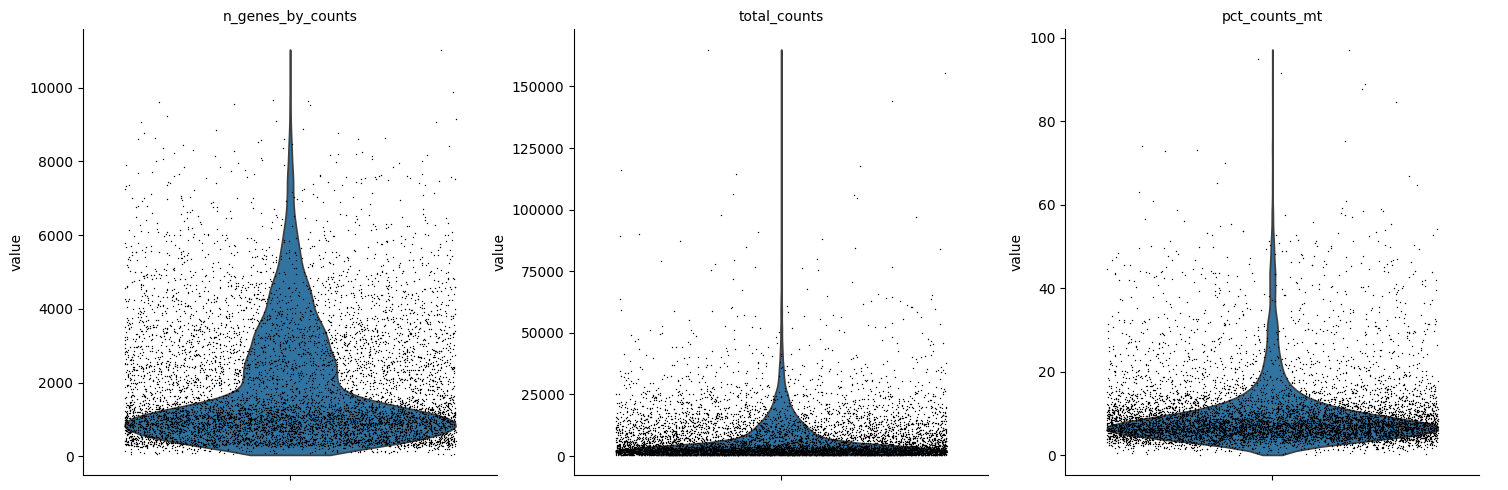

In [23]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

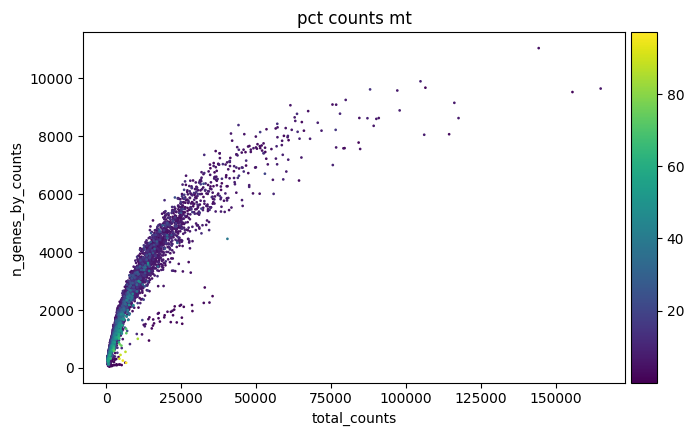

In [24]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


In [25]:
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].mean()

n_genes_by_counts    1888.624628
total_counts         7099.786621
pct_counts_mt          10.056926
dtype: float64

In [26]:
adata.obs['total_counts'].describe()

count      8056.000000
mean       7099.786621
std       10364.338867
min         500.000000
25%        1742.750000
50%        3176.500000
75%        8679.750000
max      164953.000000
Name: total_counts, dtype: float64

In [27]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [28]:
sc.pp.scrublet(adata, batch_key="sample")

In [29]:
adata = adata[adata.obs.n_genes_by_counts > 300, :]
adata = adata[adata.obs.n_genes_by_counts < 5000, :]

adata = adata[adata.obs.total_counts > 1000, :]
adata = adata[adata.obs.total_counts < 25000, :]

adata = adata[adata.obs.pct_counts_mt < 15, :]

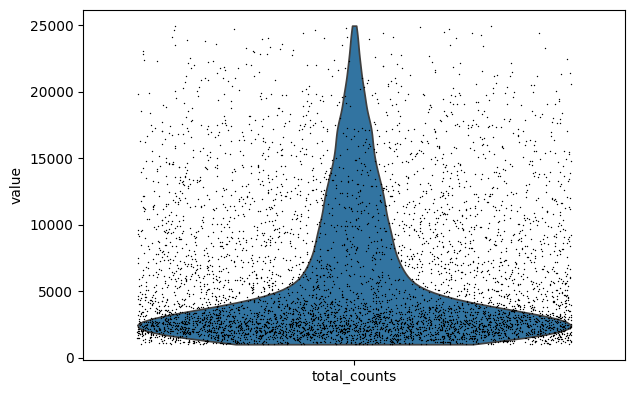

In [30]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4)

In [31]:
adata.layers['counts'] = adata.X.copy() # save counts (before norm)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_22905/374595293.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy() # save counts (before norm)


In [32]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [35]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [38]:
# keep only the HVGs 
adata = adata[:, adata.var.highly_variable]

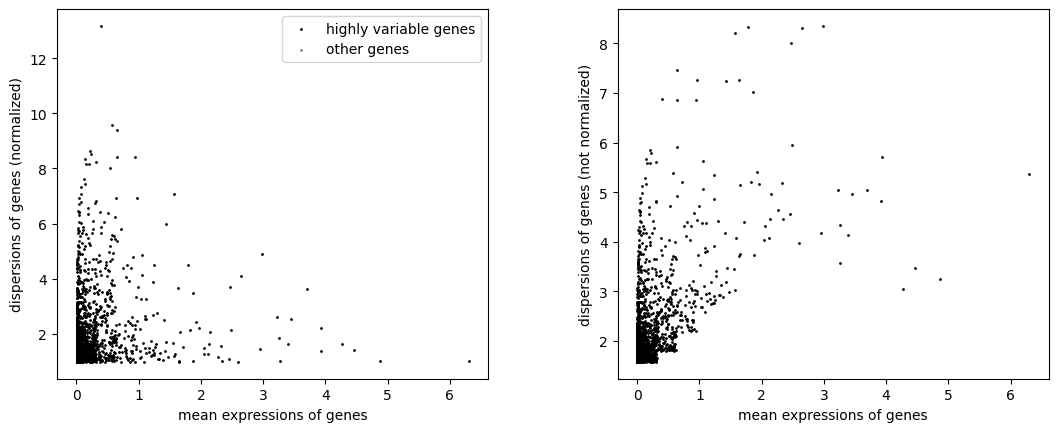

In [39]:
sc.pl.highly_variable_genes(adata)

In [40]:
sc.pp.scale(adata, max_value=10)

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/iriskwon/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
sc.tl.pca(adata, svd_solver='arpack')

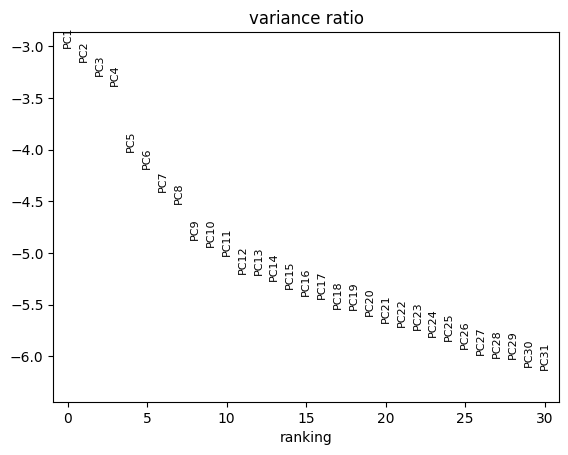

In [42]:
sc.pl.pca_variance_ratio(adata, log=True)

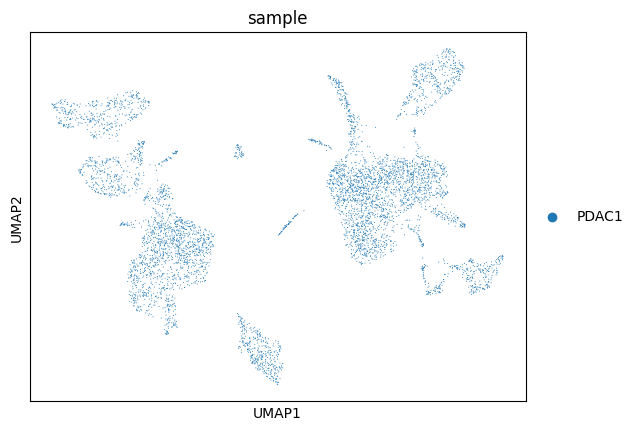

In [58]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

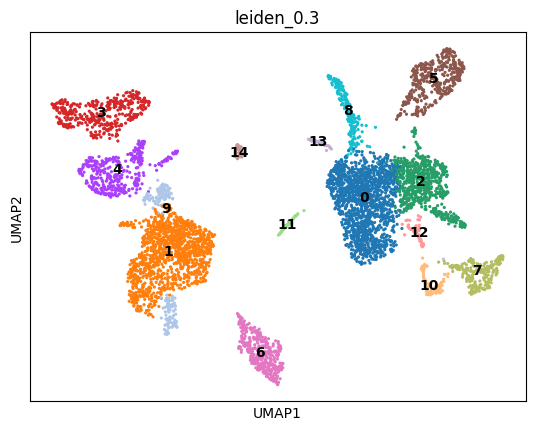

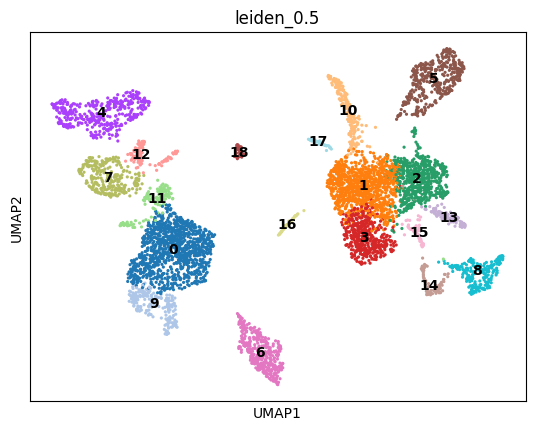

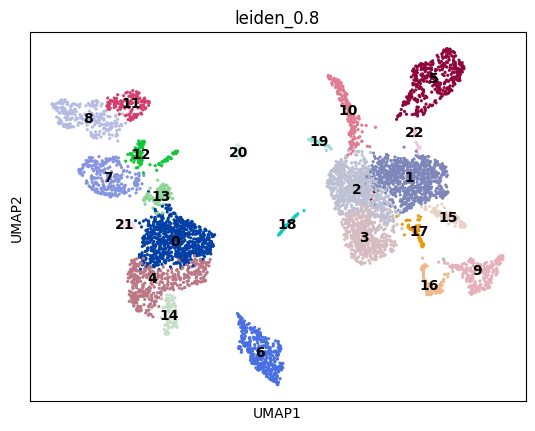

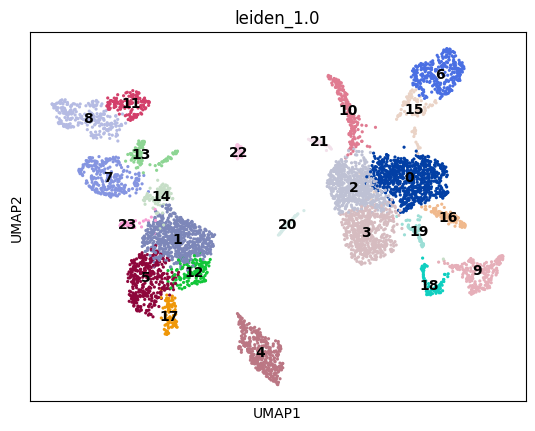

In [55]:
for r in [0.3, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=r, key_added=f'leiden_{r}')
    sc.pl.umap(adata, color=[f'leiden_{r}'], legend_loc="on data")

In [59]:
sc.tl.leiden(adata, resolution=0.5)

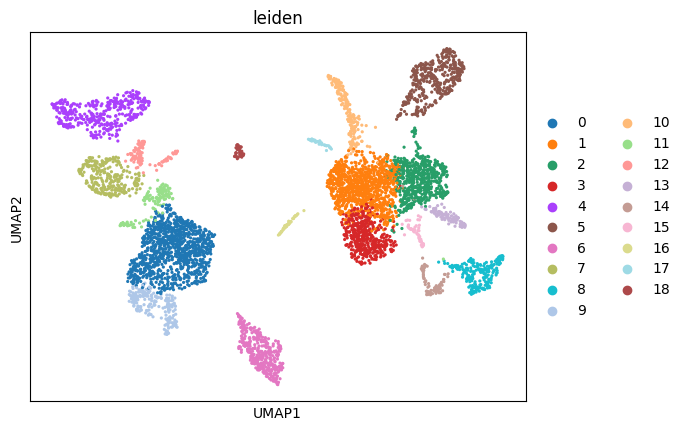

In [60]:
sc.pl.umap(adata, color=['leiden'])

In [61]:
# Find marker genes 
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/iriskwon/.local/share/virtualenvs/STalign-hu3yymDJ/lib/python3.12/sit

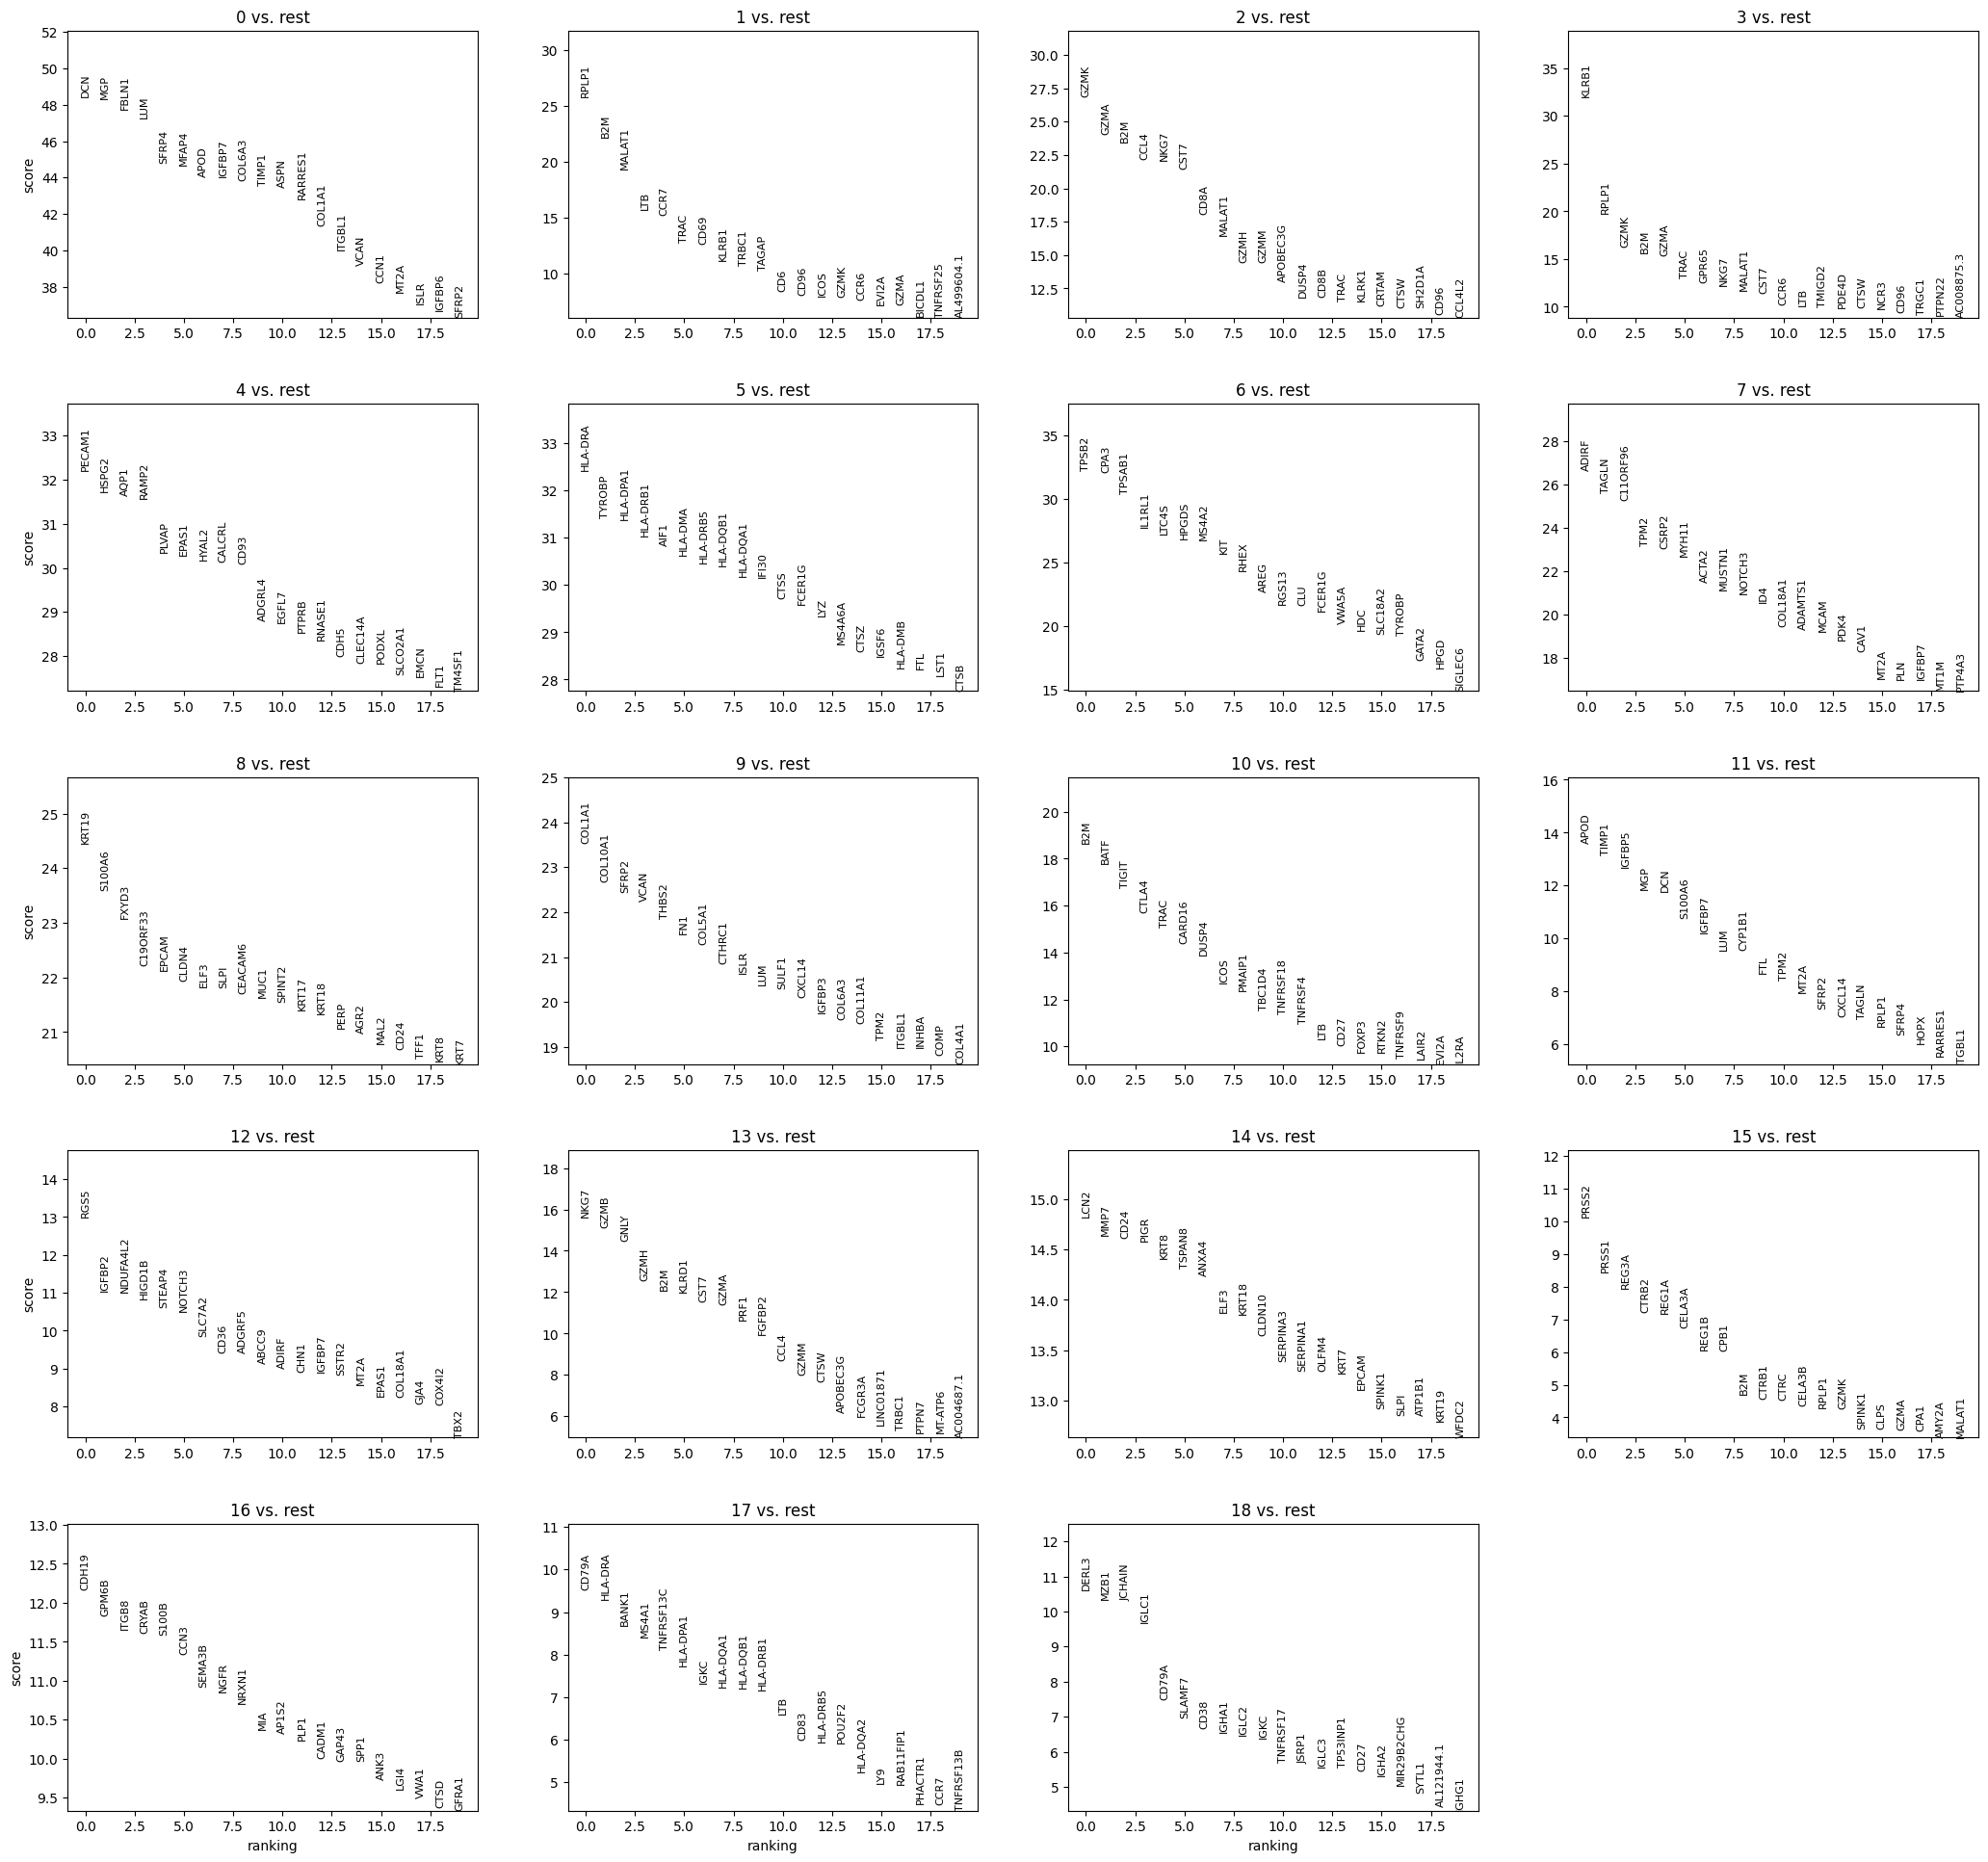

In [62]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

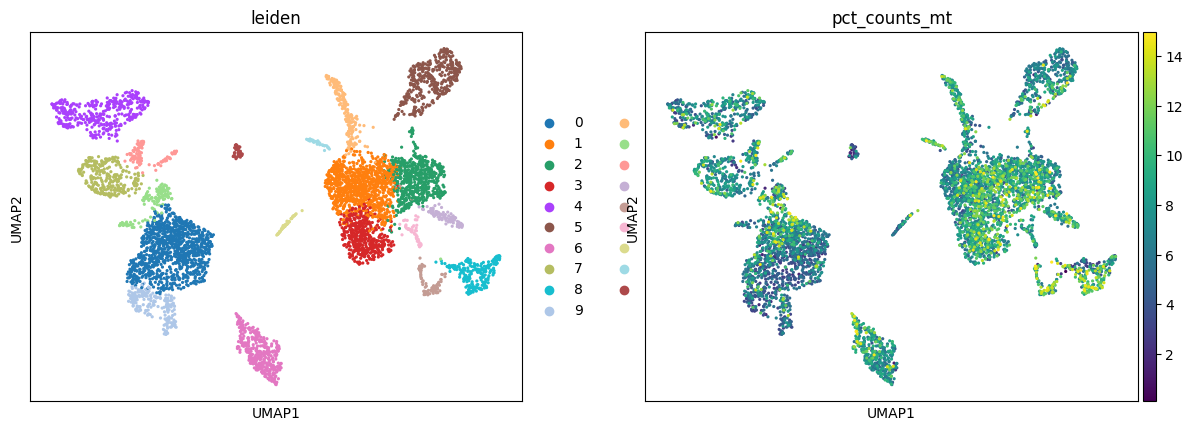

In [63]:
sc.pl.umap(adata, color=['leiden', 'pct_counts_mt'])

In [64]:
print(adata.obs.columns)

Index(['gsm', 'sample', 'condition', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes',
       'doublet_score', 'predicted_doublet', 'leiden_0.3', 'leiden_0.5',
       'leiden_0.8', 'leiden_1.0', 'leiden'],
      dtype='object')


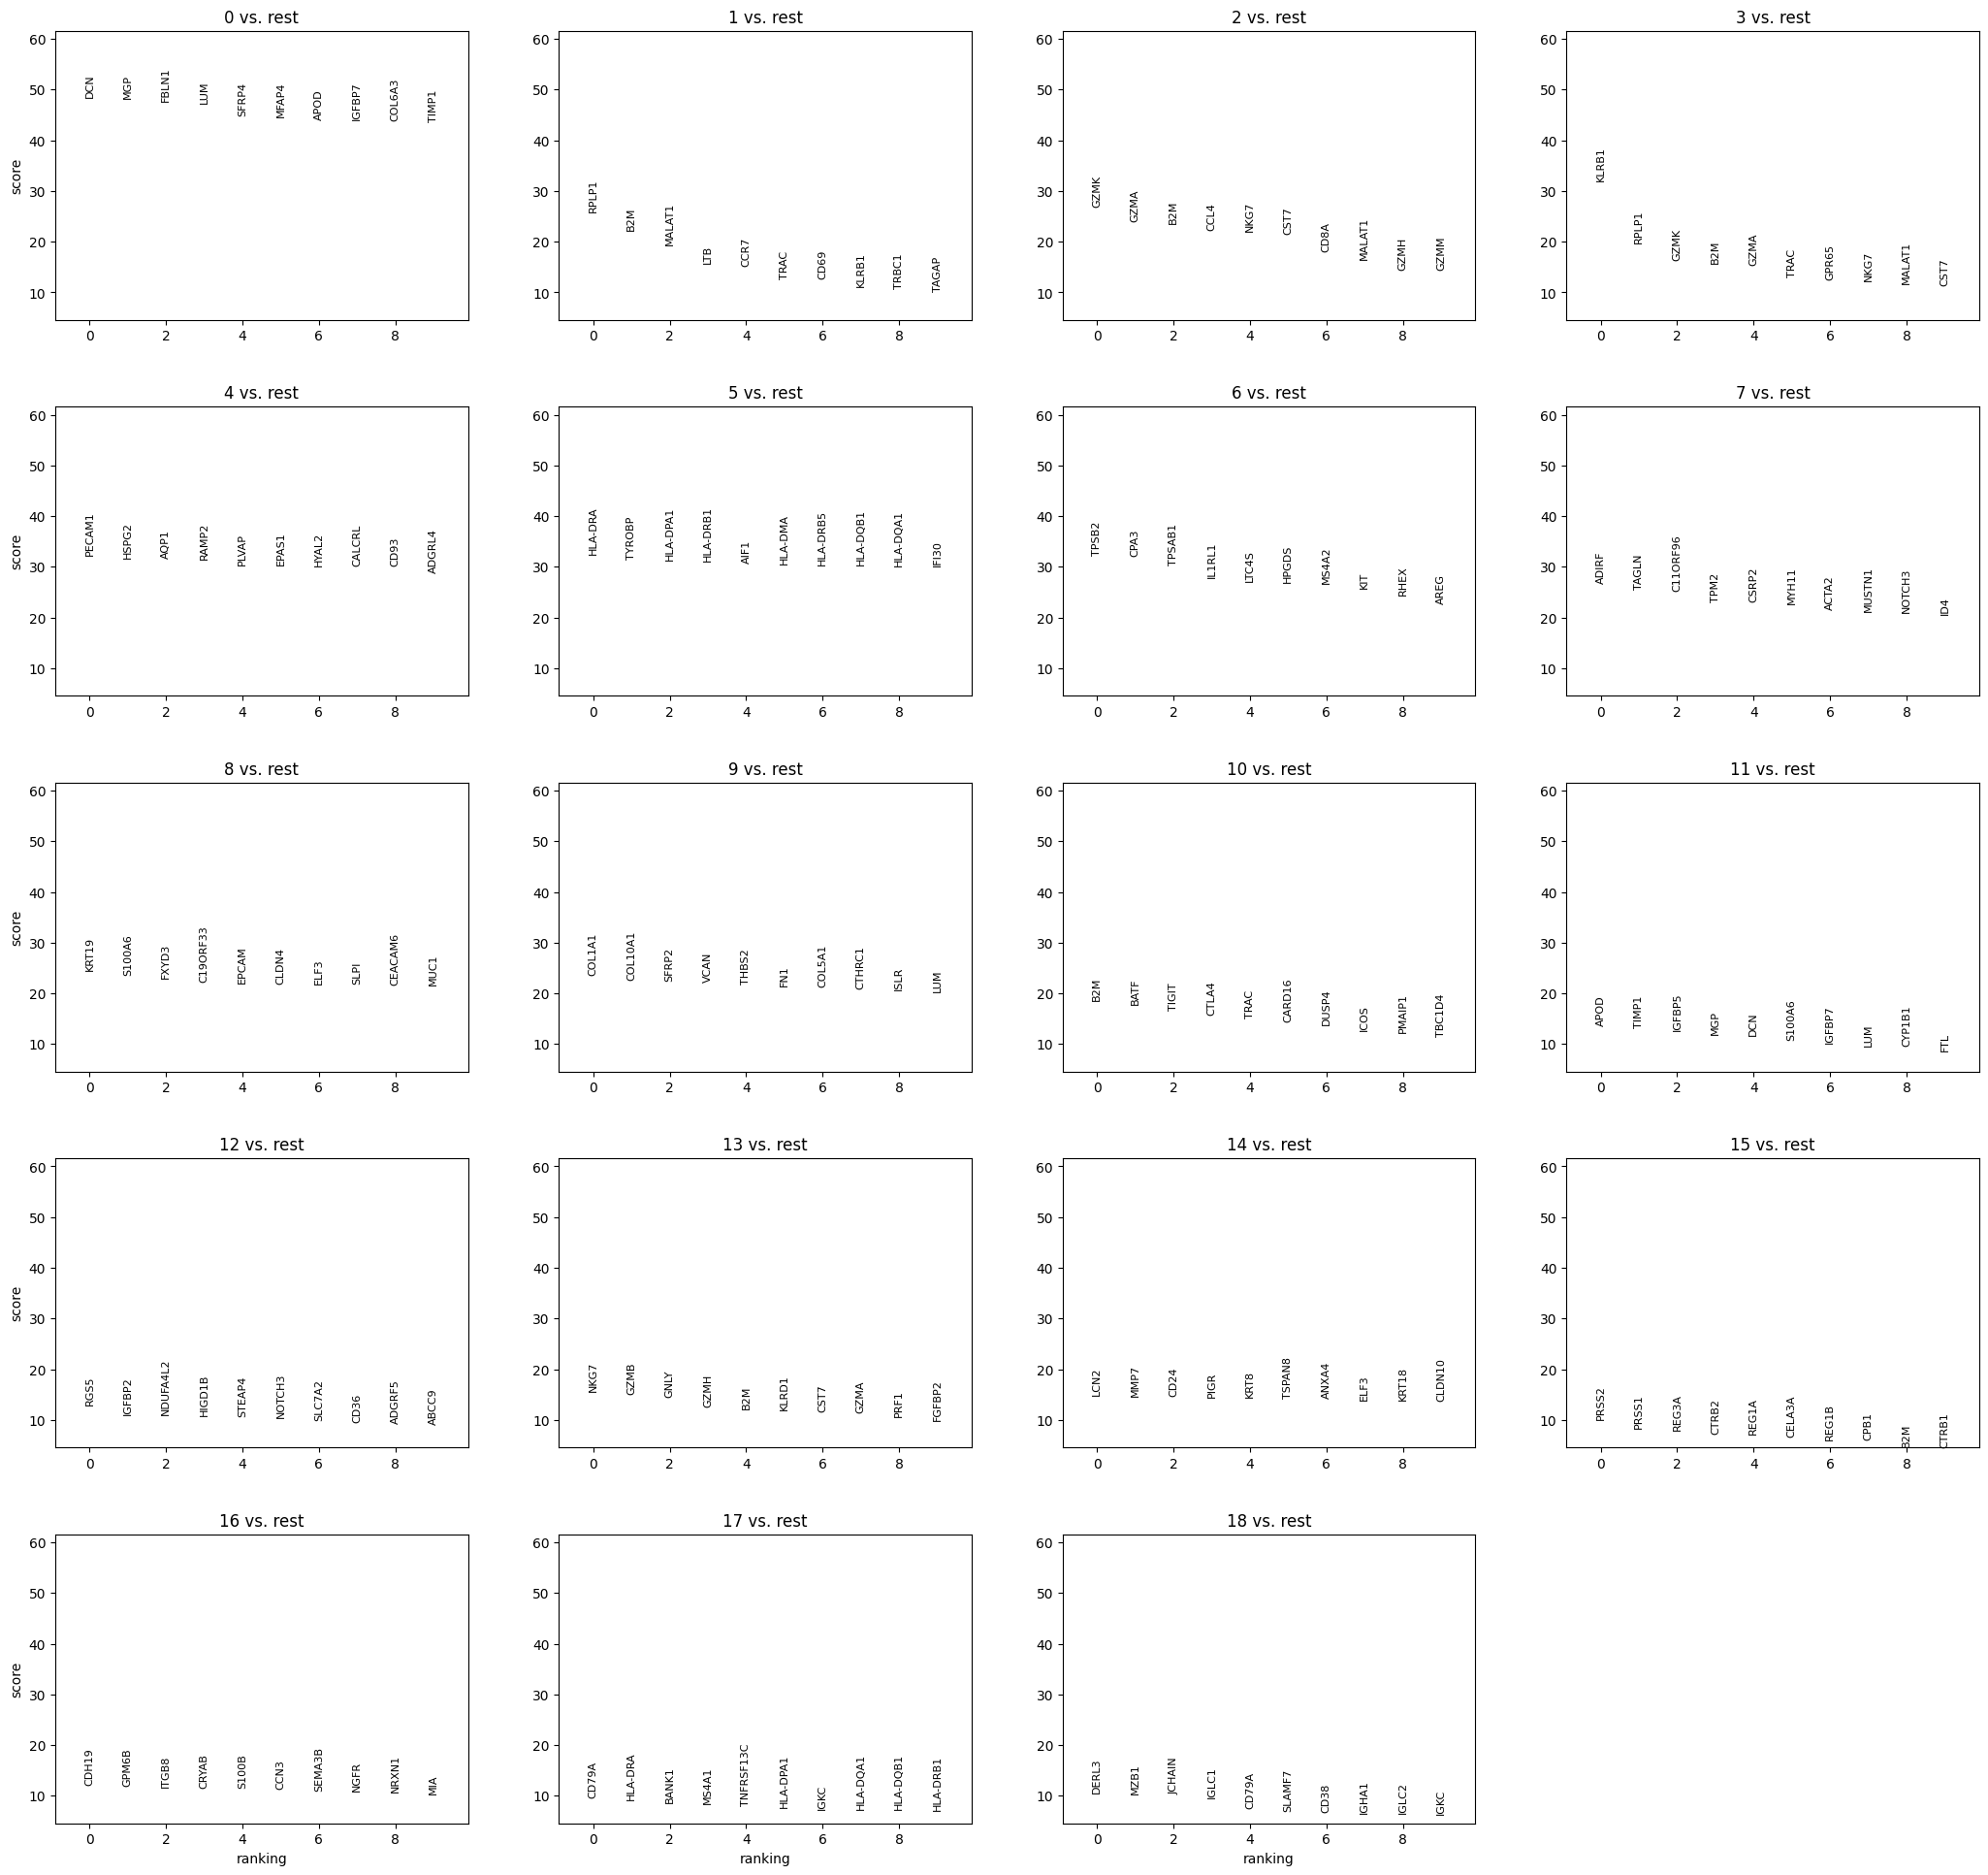

In [65]:
sc.pl.rank_genes_groups(adata, n_genes=10)

In [66]:
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
print(markers.head())

       0       1     2      3       4         5       6         7         8  \
0    DCN   RPLP1  GZMK  KLRB1  PECAM1   HLA-DRA   TPSB2     ADIRF     KRT19   
1    MGP     B2M  GZMA  RPLP1   HSPG2    TYROBP    CPA3     TAGLN    S100A6   
2  FBLN1  MALAT1   B2M   GZMK    AQP1  HLA-DPA1  TPSAB1  C11ORF96     FXYD3   
3    LUM     LTB  CCL4    B2M   RAMP2  HLA-DRB1  IL1RL1      TPM2  C19ORF33   
4  SFRP4    CCR7  NKG7   GZMA   PLVAP      AIF1   LTC4S     CSRP2     EPCAM   

         9     10      11        12    13    14     15     16         17  \
0   COL1A1    B2M    APOD      RGS5  NKG7  LCN2  PRSS2  CDH19      CD79A   
1  COL10A1   BATF   TIMP1    IGFBP2  GZMB  MMP7  PRSS1  GPM6B    HLA-DRA   
2    SFRP2  TIGIT  IGFBP5  NDUFA4L2  GNLY  CD24  REG3A  ITGB8      BANK1   
3     VCAN  CTLA4     MGP    HIGD1B  GZMH  PIGR  CTRB2  CRYAB      MS4A1   
4    THBS2   TRAC     DCN    STEAP4   B2M  KRT8  REG1A  S100B  TNFRSF13C   

       18  
0   DERL3  
1    MZB1  
2  JCHAIN  
3   IGLC1  
4   CD79

Guessing from ranked gene markers per cluster...

In [67]:
cluster_to_celltype = {
    '0': 'Fibroblasts',
    '1': 'T cells',
    '2': 'CD8+ T cells',
    '3': 'NK / activated T',
    '4': 'Endothelial',
    '5': 'Macrophages', # Myeloid cells
    '6': 'Mast cells',
    '7': 'Smooth muscle',
    '8': 'Tumor cells',
    '9': 'Fibroblasts (CAF)',
    '10': 'Exhausted T cells',
    '11': 'Tumor cells',
    '12': 'Hypoxic tumor',
    '13': 'CD8+ T cells',
    '14': 'Tumor cells',
    '15': 'Acinar cells',
    '16': 'Neural-like',
    '17': 'B cells',
    '18': 'Plasma cells'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

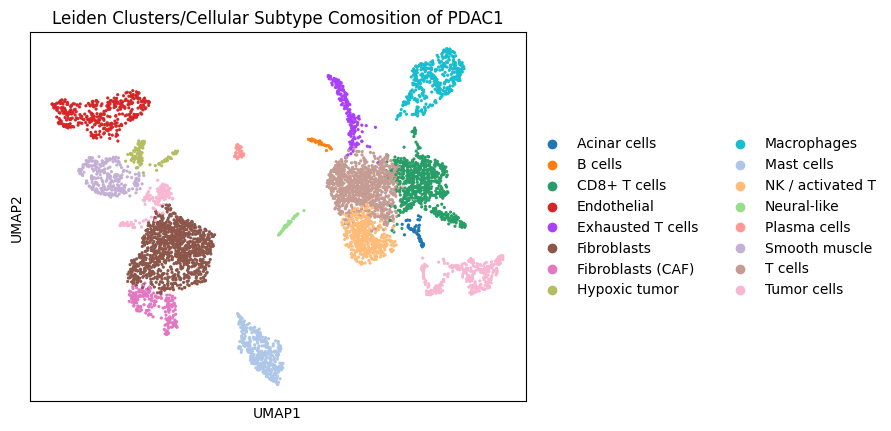

In [73]:
sc.pl.umap(
    adata,
    color=['cell_type'],
    title=[
        "Leiden Clusters/Cellular Subtype Comosition of PDAC1"
    ]
)